YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Epoch 1/100


c:\Users\User\anaconda3\envs\stockenv\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0109
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.2182e-04
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.9325e-04
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.1741e-04
Epoch 5/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.8555e-04
Epoch 6/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.5199e-04
Epoch 7/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.5486e-04
Epoch 8/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2528e-04
Epoch 9/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2237e-04
Epoch 10/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.0352e-04
Epoch 11/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.6224e-04
Epoch 12/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2086e-04
Epoch 13/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6419e-04
Epoch 14/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.9820e-04
Epoch 15/100
77/77 ━━━━━━━━━━━━

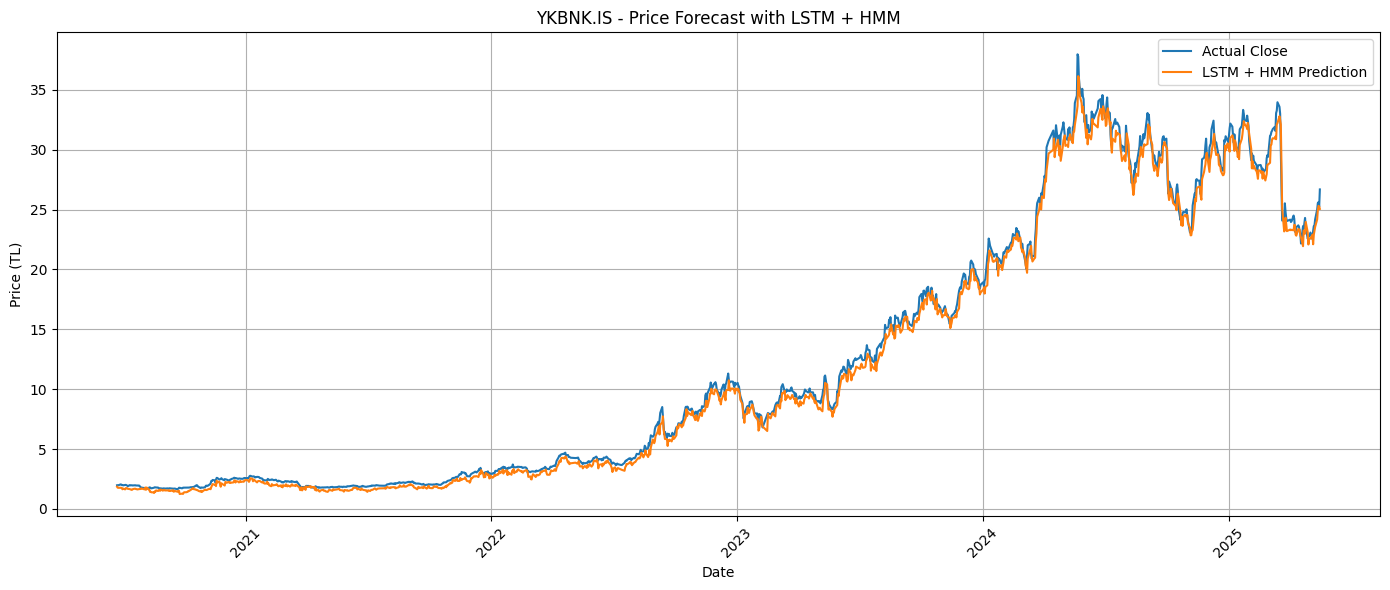

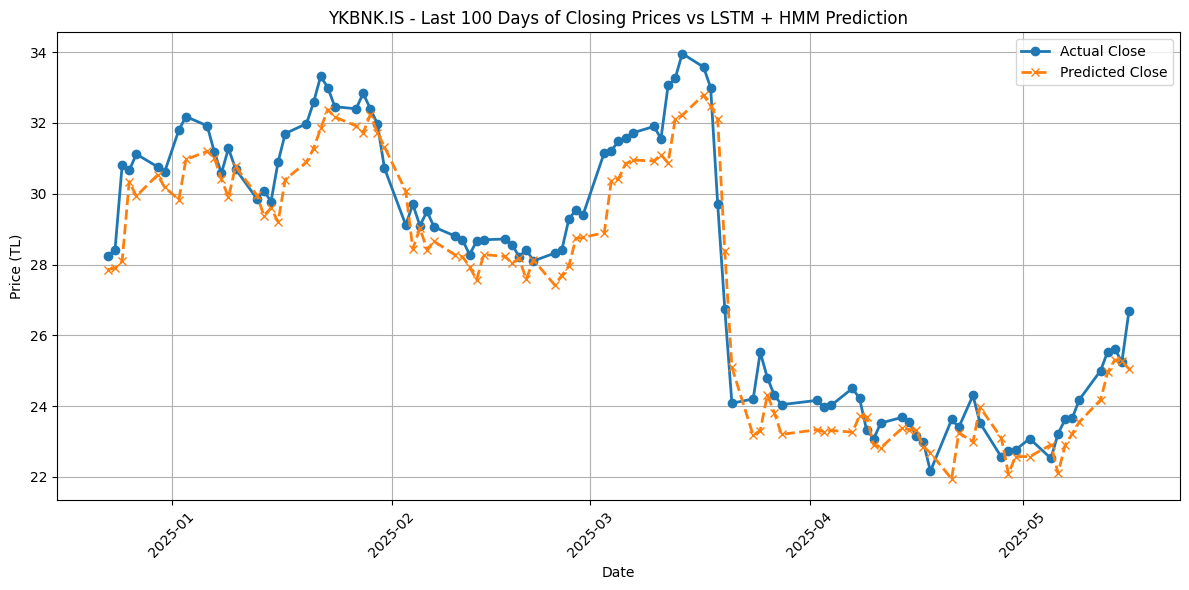

📊 Test Results
MAE  : 0.5225
MSE  : 0.4640
RMSE : 0.6812
MAPE : 7.66%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
📈 Predicted next day closing price: 26.27 TL


c:\Users\User\anaconda3\envs\stockenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\User\AppData\Local\Temp\ipykernel_15164\2820988019.py:216: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  X_shap = X_shap.drop(columns=['Close'])


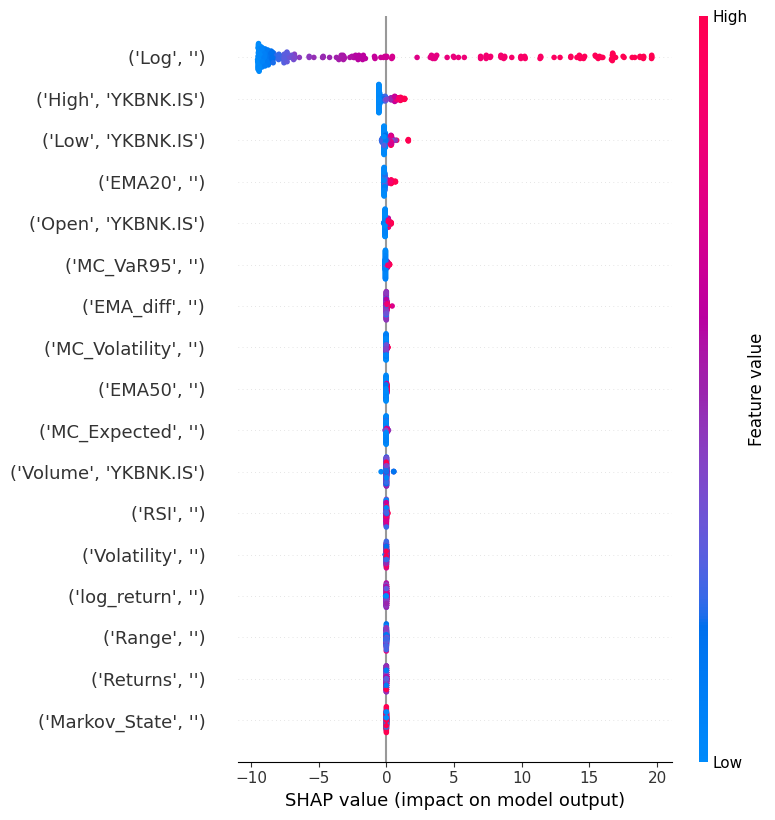

In [ ]:
#### Hmm Stateli ###

# monte carlo + HMM + LSTM + talib
import yfinance as yf
import numpy as np
import pandas as pd
from hmmlearn import hmm
import talib
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

symbol = "YKBNK.IS"  # Symbol for FROTO
# 1. Fetch data
df = yf.download(symbol, start="2020-01-01", end="2025-05-17")[['Open', 'High', 'Low', 'Close','Volume']].dropna()

# 2. Technical indicators + log return
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
close_array = df['Close'].to_numpy().ravel()

# RSI, EMA
df['RSI'] = talib.RSI(close_array, timeperiod=14)
df['EMA20'] = talib.EMA(close_array, timeperiod=20)
df['EMA50'] = talib.EMA(close_array, timeperiod=50)
df['EMA_diff'] = df['EMA20'] - df['EMA50']

# Volatility
df['Volatility'] = df['log_return'].rolling(window=10).std()

# Normalize volume
df['Log'] = np.log(df['Close'])
df['Returns'] = df['Log'].pct_change()
df['Range'] = (df['High'] / df['Low']) - 1

# Drop NaN values
df.dropna(inplace=True)

def monte_carlo_features(df, window=60, num_simulations=200, days=10):
    expected_prices = []
    volatilities = []
    var_95s = []

    for i in range(len(df)):
        if i < window:
            expected_prices.append(np.nan)
            volatilities.append(np.nan)
            var_95s.append(np.nan)
            continue

        temp_df = df.iloc[i-window:i]
        log_returns = np.log(1 + temp_df['Close'].pct_change().dropna())
        last_price = float(temp_df['Close'].iloc[-1].item())

        simulations = np.zeros((num_simulations, days))
        for j in range(num_simulations):
            random_walk = np.random.normal(log_returns.mean(), log_returns.std(), days)
            simulations[j, :] = last_price * np.exp(np.cumsum(random_walk))  # 👈 Proper array assignment

        expected_prices.append(simulations.mean(axis=0)[-1])
        volatilities.append(simulations.std(axis=0)[-1])
        var_95s.append(np.percentile(simulations[:, -1], 5))

    df['MC_Expected'] = expected_prices
    df['MC_Volatility'] = volatilities
    df['MC_VaR95'] = var_95s
    return df

df = monte_carlo_features(df)

def markov_states(prices, volumes):
    # Ensure we have 1D Series
    if isinstance(prices, pd.DataFrame):
        prices = prices.iloc[:, 0]
    if isinstance(volumes, pd.DataFrame):
        volumes = volumes.iloc[:, 0]

    prices = pd.to_numeric(prices, errors='coerce')
    volumes = pd.to_numeric(volumes, errors='coerce')

    changes = prices.diff().fillna(0) * volumes.diff().fillna(0)
    states = []
    for change in changes:
        if change > 0:
            states.append(2)  # Increase
        elif change < 0:
            states.append(0)  # Decrease
        else:
            states.append(1)  # Stable
    return pd.Series(states, index=prices.index)



df['Markov_State'] = markov_states(df['Close'], df['Volume'])

df.dropna(inplace=True)

obs= df.copy()
df.dropna(inplace=True)

# 3. Normalization (for LSTM)
scaler = MinMaxScaler()
scaled = scaler.fit_transform(obs)

# 4. Create LSTM dataset
def create_lstm_data(data, seq_len=10):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len][3])  # Close price is the target
    return np.array(X), np.array(y)

X, y = create_lstm_data(scaled)

early_stop = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

# 5. Define LSTM model
model_lstm = Sequential([
    LSTM(64, activation='relu', input_shape=(X.shape[1], X.shape[2])),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X, y, epochs=100, batch_size=16, verbose=1, callbacks=[early_stop])

# 6. Prediction
predicted = model_lstm.predict(X)

# 7. Rescale predictions
predicted_full = np.zeros((len(predicted), scaled.shape[1]))
predicted_full[:, 3] = predicted[:, 0]  # Only Close
restored = scaler.inverse_transform(predicted_full)[:, 3]

# 8. Compare with real prices
real_close = df['Close'].iloc[-len(restored):].values

# 9. Plot
dates = df.index[-len(restored):]

plt.figure(figsize=(14, 6))
plt.plot(dates, real_close, label='Actual Close')
plt.plot(dates, restored, label='LSTM + HMM Prediction')
plt.title('YKBNK.IS - Price Forecast with LSTM + HMM')
plt.xlabel('Date')
plt.ylabel('Price (TL)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Properly aligned actual closing prices
seq_len = 10  # LSTM window
real_close = df['Close'].iloc[seq_len:seq_len + len(restored)].values
dates = df.index[seq_len:seq_len + len(restored)]  # Dates for x-axis

# Take the last 100 days
real_last_30 = real_close[-100:]
pred_last_30 = restored[-100:]
dates_last_30 = dates[-100:]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(dates_last_30, real_last_30, marker='o', label='Actual Close', linewidth=2)
plt.plot(dates_last_30, pred_last_30, marker='x', linestyle='--', label='Predicted Close', linewidth=2)
plt.title("YKBNK.IS - Last 100 Days of Closing Prices vs LSTM + HMM Prediction")
plt.xlabel("Date")
plt.ylabel("Price (TL)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Comparison for last 100 days
actual = real_close
predicted = restored

# Performance metrics
mae = mean_absolute_error(actual, predicted)
mse = mean_squared_error(actual, predicted)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(actual, predicted) * 100

print("📊 Test Results")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

# 🔚 Predict the next day
last_sequence = scaled[-10:]  # Last 10 days
last_sequence = np.expand_dims(last_sequence, axis=0)  # Shape for LSTM (1, 10, features)

# Prediction
next_day_scaled = model_lstm.predict(last_sequence)

# Dummy array for inverse scaling
dummy_input = np.zeros((1, scaled.shape[1]))
dummy_input[0, 3] = next_day_scaled[0, 0]  # 3: Index of Close in scaled data

# Get the original scale closing price
next_day_close = scaler.inverse_transform(dummy_input)[0, 3]

print(f"📈 Predicted next day closing price: {next_day_close:.2f} TL")

import shap
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Features and target variable
X_shap = obs.copy()
y_shap = X_shap['Close']
X_shap = X_shap.drop(columns=['Close'])

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_shap, y_shap, test_size=0.2, random_state=42)

# 3. Train the model
model = XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Compute SHAP values
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# 5. Summary plot (feature importance)
shap.summary_plot(shap_values, X_test)


[*********************100%***********************]  1 of 1 completed


Epoch 1/100


c:\Users\User\anaconda3\envs\stockenv\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0622
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7724e-04
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.9808e-04
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.6978e-04
Epoch 5/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.4175e-04
Epoch 6/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.4981e-04
Epoch 7/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.5144e-04
Epoch 8/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.3309e-04
Epoch 9/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.7011e-04
Epoch 10/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7006e-04
Epoch 11/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.5759e-04
Epoch 12/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.5516e-04
Epoch 13/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.4995e-04
Epoch 14/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.8148e-04
Epoch 15/100
77/77 ━━━━━━━━━━━━

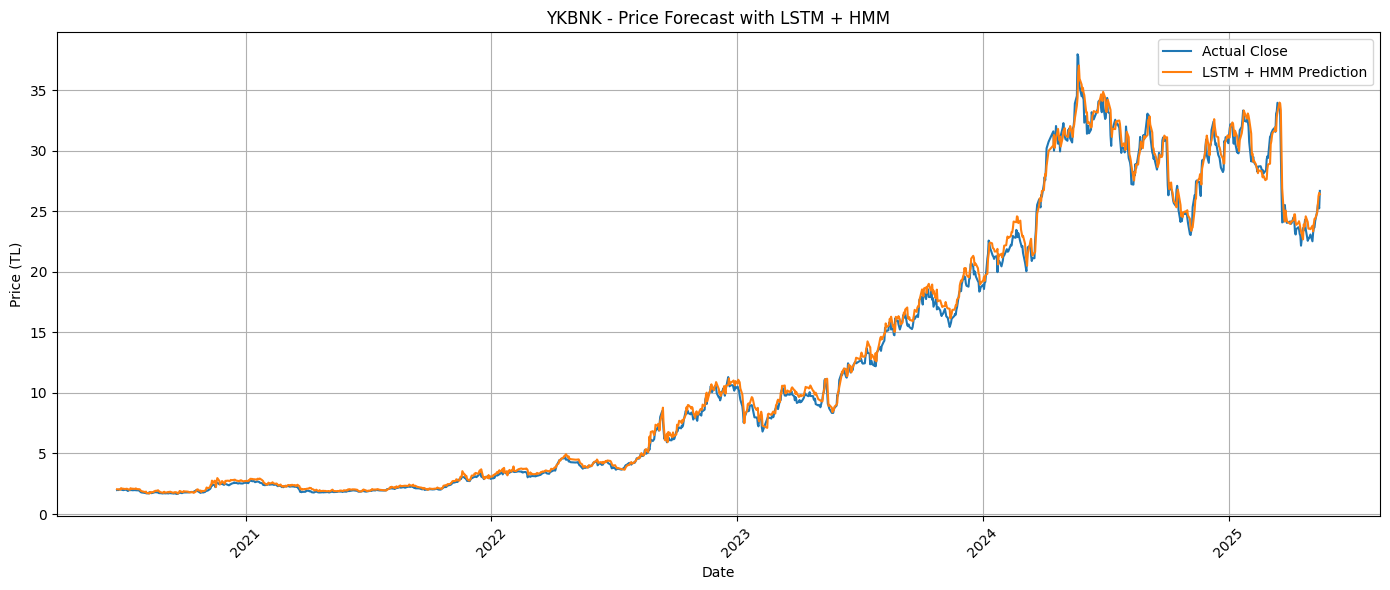

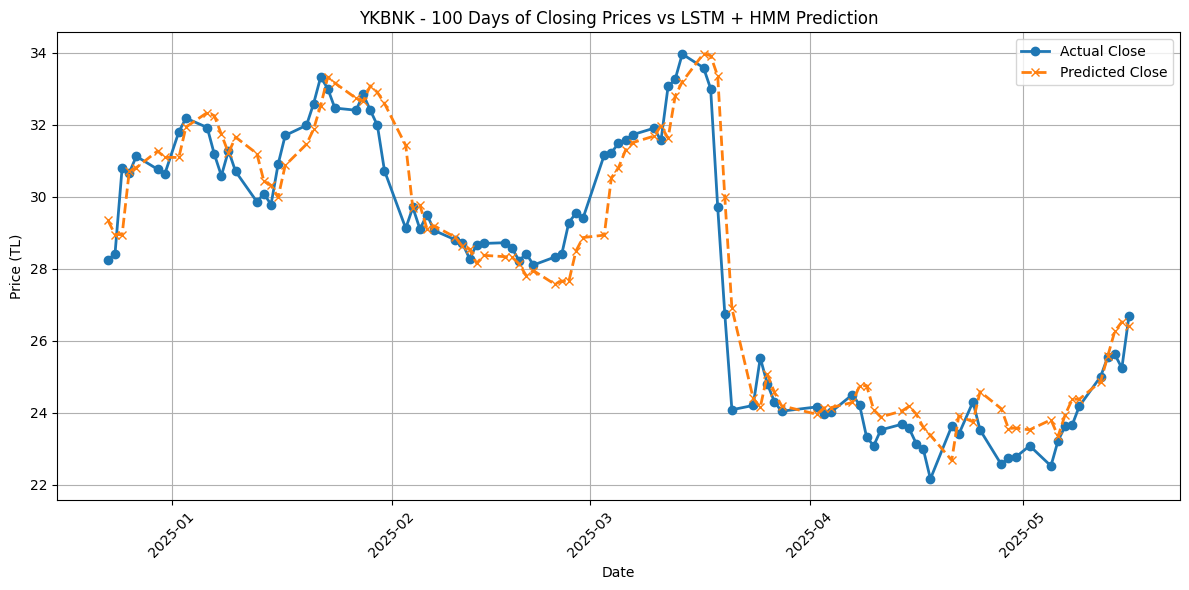

📊 Test Results
MAE  : 0.3975
MSE  : 0.3447
RMSE : 0.5871
MAPE : 4.28%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
📈 Predicted next day closing price: 27.59 TL


In [ ]:
#### Hmm Stateli ###

# monte carlo + HMM + LSTM + talib
import yfinance as yf
import numpy as np
import pandas as pd
from hmmlearn import hmm
import talib
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

symbol = "YKBNK.IS"  # Symbol for FROTO
# 1. Fetch data
df = yf.download(symbol, start="2020-01-01", end="2025-05-17")[['Open', 'High', 'Low', 'Close','Volume']].dropna()

# 2. Technical indicators + log return
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
close_array = df['Close'].to_numpy().ravel()

# RSI, EMA
df['RSI'] = talib.RSI(close_array, timeperiod=14)
df['EMA20'] = talib.EMA(close_array, timeperiod=20)
df['EMA50'] = talib.EMA(close_array, timeperiod=50)
df['EMA_diff'] = df['EMA20'] - df['EMA50']

# Volatility
df['Volatility'] = df['log_return'].rolling(window=10).std()

# Normalize volume
df['Log'] = np.log(df['Close'])
df['Returns'] = df['Log'].pct_change()
df['Range'] = (df['High'] / df['Low']) - 1

# Drop NaN values
df.dropna(inplace=True)

def monte_carlo_features(df, window=60, num_simulations=200, days=10):
    expected_prices = []
    volatilities = []
    var_95s = []

    for i in range(len(df)):
        if i < window:
            expected_prices.append(np.nan)
            volatilities.append(np.nan)
            var_95s.append(np.nan)
            continue

        temp_df = df.iloc[i-window:i]
        log_returns = np.log(1 + temp_df['Close'].pct_change().dropna())
        last_price = float(temp_df['Close'].iloc[-1].item())

        simulations = np.zeros((num_simulations, days))
        for j in range(num_simulations):
            random_walk = np.random.normal(log_returns.mean(), log_returns.std(), days)
            simulations[j, :] = last_price * np.exp(np.cumsum(random_walk))  # 👈 Proper array assignment

        expected_prices.append(simulations.mean(axis=0)[-1])
        volatilities.append(simulations.std(axis=0)[-1])
        var_95s.append(np.percentile(simulations[:, -1], 5))

    df['MC_Expected'] = expected_prices
    df['MC_Volatility'] = volatilities
    df['MC_VaR95'] = var_95s
    return df

df = monte_carlo_features(df)

# HMM State
obs = df.copy()
obs = obs.replace([np.inf, -np.inf], np.nan).dropna()
hmm_model = hmm.GaussianHMM(n_components=2, n_iter=100, random_state=42)
hmm_model.fit(obs)
obs['HMM_State'] = hmm_model.predict(obs)

df.dropna(inplace=True)

# 3. Normalization (for LSTM)
scaler = MinMaxScaler()
scaled = scaler.fit_transform(obs)

# 4. Create LSTM dataset
def create_lstm_data(data, seq_len=10):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len][3])  # Close price is the target
    return np.array(X), np.array(y)

X, y = create_lstm_data(scaled)

early_stop = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

# 5. Define LSTM model
model_lstm = Sequential([
    LSTM(64, activation='relu', input_shape=(X.shape[1], X.shape[2])),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X, y, epochs=100, batch_size=16, verbose=1, callbacks=[early_stop])

# 6. Prediction
predicted = model_lstm.predict(X)

# 7. Rescale predictions
predicted_full = np.zeros((len(predicted), scaled.shape[1]))
predicted_full[:, 3] = predicted[:, 0]  # Only Close
restored = scaler.inverse_transform(predicted_full)[:, 3]

# 8. Compare with real prices
real_close = df['Close'].iloc[-len(restored):].values

# 9. Plot
dates = df.index[-len(restored):]

plt.figure(figsize=(14, 6))
plt.plot(dates, real_close, label='Actual Close')
plt.plot(dates, restored, label='LSTM + HMM Prediction')
plt.title('YKBNK - Price Forecast with LSTM + HMM')
plt.xlabel('Date')
plt.ylabel('Price (TL)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Properly aligned actual closing prices
seq_len = 10  # LSTM window
real_close = df['Close'].iloc[seq_len:seq_len + len(restored)].values
dates = df.index[seq_len:seq_len + len(restored)]  # Dates for x-axis

# Take the last 100 days
real_last_30 = real_close[-100:]
pred_last_30 = restored[-100:]
dates_last_30 = dates[-100:]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(dates_last_30, real_last_30, marker='o', label='Actual Close', linewidth=2)
plt.plot(dates_last_30, pred_last_30, marker='x', linestyle='--', label='Predicted Close', linewidth=2)
plt.title("YKBNK - 100 Days of Closing Prices vs LSTM + HMM Prediction")
plt.xlabel("Date")
plt.ylabel("Price (TL)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Comparison for last 100 days
actual = real_close
predicted = restored

# Performance metrics
mae = mean_absolute_error(actual, predicted)
mse = mean_squared_error(actual, predicted)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(actual, predicted) * 100

print("📊 Test Results")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

# 🔚 Predict the next day
last_sequence = scaled[-10:]  # Last 10 days
last_sequence = np.expand_dims(last_sequence, axis=0)  # Shape for LSTM (1, 10, features)

# Prediction
next_day_scaled = model_lstm.predict(last_sequence)

# Dummy array for inverse scaling
dummy_input = np.zeros((1, scaled.shape[1]))
dummy_input[0, 3] = next_day_scaled[0, 0]  # 3: Index of Close in scaled data

# Get the original scale closing price
next_day_close = scaler.inverse_transform(dummy_input)[0, 3]

print(f"📈 Predicted next day closing price: {next_day_close:.2f} TL")


[*********************100%***********************]  1 of 1 completed


Epoch 1/100


C:\Users\User\AppData\Local\Temp\ipykernel_10248\1458654640.py:82: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  obs.drop(columns=['Prev_HMM_State'], inplace=True)
c:\Users\User\anaconda3\envs\stockenv\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0750
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.6937e-04
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1530e-04
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.4899e-04
Epoch 5/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.3243e-04
Epoch 6/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.5605e-04
Epoch 7/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.7240e-04
Epoch 8/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.1440e-04
Epoch 9/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.2699e-04
Epoch 10/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.6157e-04
Epoch 11/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.8113e-04
Epoch 12/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2544e-04
Epoch 13/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.3811e-04
Epoch 14/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.4225e-04
Epoch 15/100
77/77 ━━━━━━━━━━━━

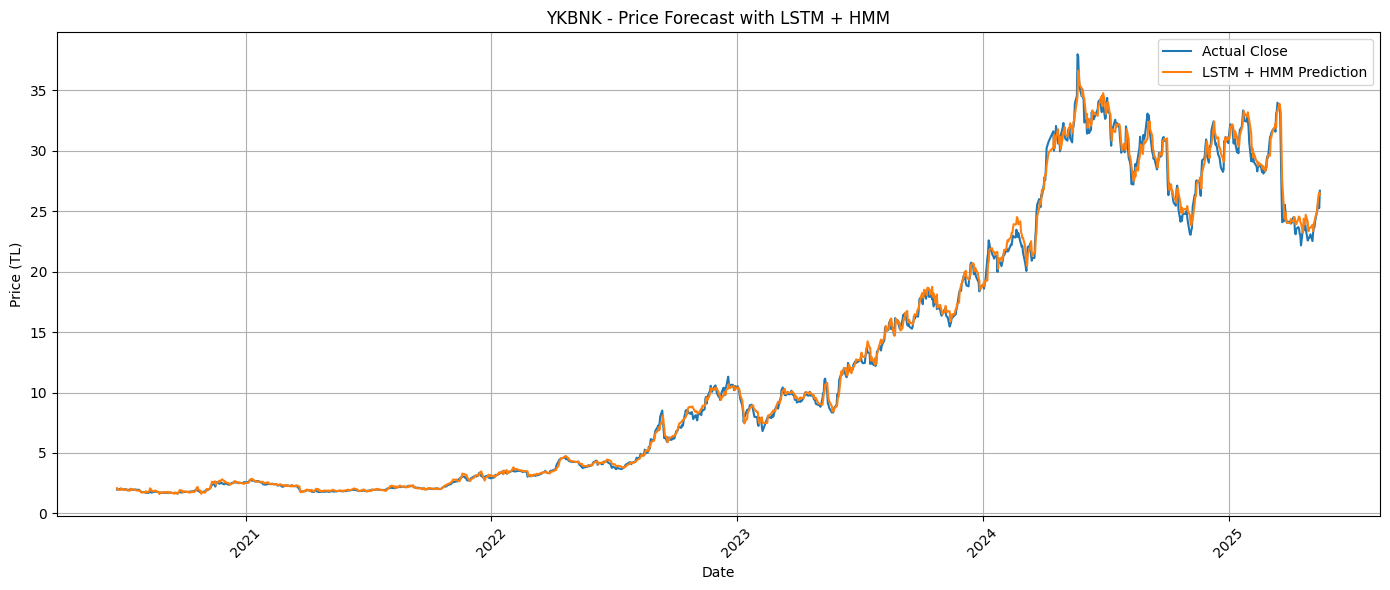

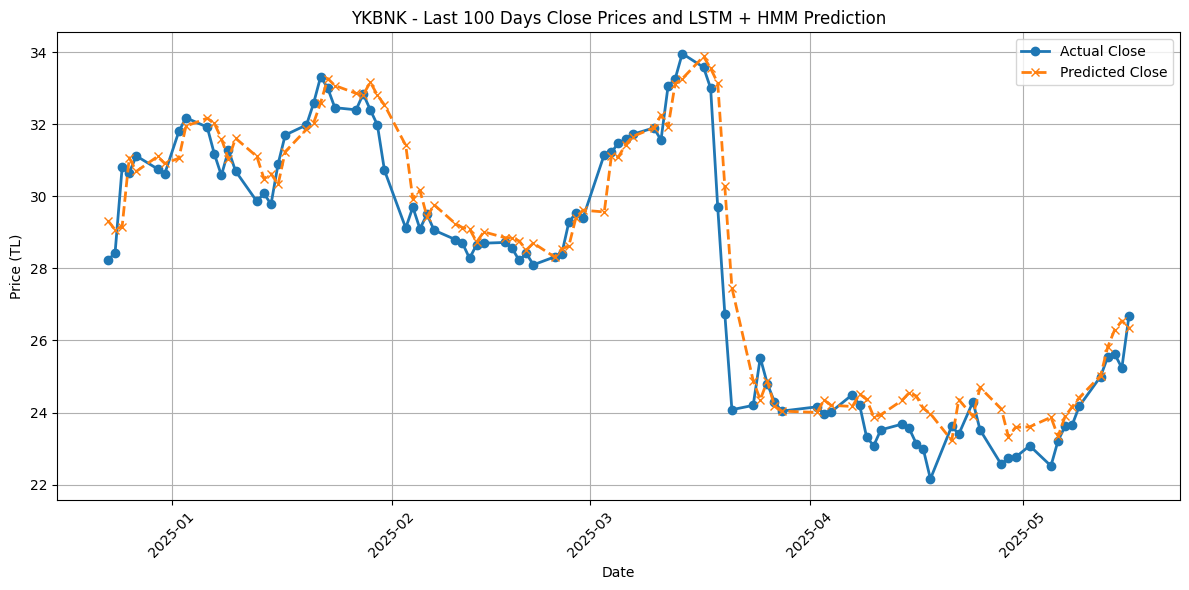

📊 Test Results
MAE  : 0.3236
MSE  : 0.2760
RMSE : 0.5254
MAPE : 3.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
📈 Predicted next day closing price: 27.63 TL


In [ ]:
#HMM PROBABABILITYLI
import yfinance as yf
import numpy as np
import pandas as pd
from hmmlearn import hmm
import talib
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

symbol = "YKBNK.IS"  # Symbol for FROTO
# 1. Fetch data
df = yf.download(symbol, start="2020-01-01", end="2025-05-17")[['Open', 'High', 'Low', 'Close','Volume']].dropna()

# 2. Technical indicators + log return
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
close_array = df['Close'].to_numpy().ravel()

# RSI, EMA
df['RSI'] = talib.RSI(close_array, timeperiod=14)
df['EMA20'] = talib.EMA(close_array, timeperiod=20)
df['EMA50'] = talib.EMA(close_array, timeperiod=50)
df['EMA_diff'] = df['EMA20'] - df['EMA50']

# Volatility
df['Volatility'] = df['log_return'].rolling(window=10).std()

# Normalize volume
df['Log'] = np.log(df['Close'])
df['Returns'] = df['Log'].pct_change()
df['Range'] = (df['High'] / df['Low']) - 1

# Drop NaNs
df.dropna(inplace=True)

def monte_carlo_features(df, window=60, num_simulations=200, days=10):
    expected_prices = []
    volatilities = []
    var_95s = []

    for i in range(len(df)):
        if i < window:
            expected_prices.append(np.nan)
            volatilities.append(np.nan)
            var_95s.append(np.nan)
            continue

        temp_df = df.iloc[i-window:i]
        log_returns = np.log(1 + temp_df['Close'].pct_change().dropna())
        last_price = float(temp_df['Close'].iloc[-1].item())

        simulations = np.zeros((num_simulations, days))
        for j in range(num_simulations):
            random_walk = np.random.normal(log_returns.mean(), log_returns.std(), days)
            simulations[j, :] = last_price * np.exp(np.cumsum(random_walk))  # 👈 Proper assignment to array

        expected_prices.append(simulations.mean(axis=0)[-1])
        volatilities.append(simulations.std(axis=0)[-1])
        var_95s.append(np.percentile(simulations[:, -1], 5))

    df['MC_Expected'] = expected_prices
    df['MC_Volatility'] = volatilities
    df['MC_VaR95'] = var_95s
    return df

df = monte_carlo_features(df)

# 4. Add HMM features
obs = df.copy()
hmm_obs = obs[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
hmm_model = hmm.GaussianHMM(n_components=2, n_iter=100, random_state=42)
hmm_model.fit(hmm_obs)
obs['HMM_State'] = hmm_model.predict(hmm_obs)
proba = hmm_model.predict_proba(hmm_obs)
obs['HMM_Prob_0'] = proba[:, 0]
obs['HMM_Prob_1'] = proba[:, 1]
obs['Prev_HMM_State'] = obs['HMM_State'].shift(1)
obs['State_Change'] = (obs['HMM_State'] != obs['Prev_HMM_State']).astype(int)
obs.drop(columns=['Prev_HMM_State'], inplace=True)
obs = obs.replace([np.inf, -np.inf], np.nan).dropna()

df.dropna(inplace=True)

# 3. Normalization (for LSTM)
scaler = MinMaxScaler()
scaled = scaler.fit_transform(obs)

# 4. Create LSTM dataset
def create_lstm_data(data, seq_len=10):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len][3])  # Close price as target
    return np.array(X), np.array(y)

X, y = create_lstm_data(scaled)

early_stop = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

# 5. Define LSTM model
model_lstm = Sequential([
    LSTM(64, activation='relu', input_shape=(X.shape[1], X.shape[2])),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X, y, epochs=100, batch_size=16, verbose=1, callbacks=[early_stop])

# 6. Prediction
predicted = model_lstm.predict(X)

# 7. Inverse scale the predictions
predicted_full = np.zeros((len(predicted), scaled.shape[1]))
predicted_full[:, 3] = predicted[:, 0]  # Only Close
restored = scaler.inverse_transform(predicted_full)[:, 3]

# 8. Compare with actual prices
real_close = df['Close'].iloc[-len(restored):].values

# 9. Plot
dates = df.index[-len(restored):]

plt.figure(figsize=(14, 6))
plt.plot(dates, real_close, label='Actual Close')
plt.plot(dates, restored, label='LSTM + HMM Prediction')
plt.title('YKBNK - Price Forecast with LSTM + HMM')
plt.xlabel('Date')
plt.ylabel('Price (TL)')
plt.xticks(rotation=45)  # Rotate date labels
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Properly aligned actual close price
seq_len = 10  # LSTM window
real_close = df['Close'].iloc[seq_len:seq_len + len(restored)].values
dates = df.index[seq_len:seq_len + len(restored)]  # Get dates for x-axis

# Take the last 100 days
real_last_30 = real_close[-100:]
pred_last_30 = restored[-100:]
dates_last_30 = dates[-100:]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(dates_last_30, real_last_30, marker='o', label='Actual Close', linewidth=2)
plt.plot(dates_last_30, pred_last_30, marker='x', linestyle='--', label='Predicted Close', linewidth=2)
plt.title("YKBNK - Last 100 Days Close Prices and LSTM + HMM Prediction")
plt.xlabel("Date")
plt.ylabel("Price (TL)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Comparison for last 100 days
actual = real_close
predicted = restored

# Performance metrics
mae = mean_absolute_error(actual, predicted)
mse = mean_squared_error(actual, predicted)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(actual, predicted) * 100

print("📊 Test Results")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

# 🔚 Predict the next day
last_sequence = scaled[-10:]  # Last 10 days
last_sequence = np.expand_dims(last_sequence, axis=0)  # Shape for LSTM (1, 10, features)

# Prediction
next_day_scaled = model_lstm.predict(last_sequence)

# Dummy array for inverse scaling
dummy_input = np.zeros((1, scaled.shape[1]))
dummy_input[0, 3] = next_day_scaled[0, 0]  # 3: Index of Close in scaled data

# Get the predicted next day's closing price in original scale
next_day_close = scaler.inverse_transform(dummy_input)[0, 3]

print(f"📈 Predicted next day closing price: {next_day_close:.2f} TL")


📊 Test Results
MAE  : 0.3912
MSE  : 0.3341
RMSE : 0.5780
MAPE : 4.94%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
📈 Predicted next day closing price: 27.97 TL

🔍 Removing feature: ('Open', 'YKBNK.IS')


c:\Users\User\anaconda3\envs\stockenv\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


🔍 Removing feature: ('High', 'YKBNK.IS')


c:\Users\User\anaconda3\envs\stockenv\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


🔍 Removing feature: ('Low', 'YKBNK.IS')


...

🔍 Removing feature: ('HMM_Prob_1', '')


c:\Users\User\anaconda3\envs\stockenv\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


🔍 Removing feature: ('State_Change', '')


c:\Users\User\anaconda3\envs\stockenv\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


                   Feature       MAE       MSE      RMSE      MAPE
18      ('HMM_Prob_0', '')  0.324333  0.241441  0.491366  3.854233
2      ('Low', 'YKBNK.IS')  0.312579  0.245787  0.495769  2.957557
11             ('Log', '')  0.318944  0.254785  0.504762  3.438805
19      ('HMM_Prob_1', '')  0.347588  0.258229  0.508162  4.433967
13           ('Range', '')  0.319368  0.260204  0.510102  2.973526
9         ('EMA_diff', '')  0.359877  0.272335  0.521858  5.197256
17       ('HMM_State', '')  0.340201  0.275828  0.525194  3.454305
14     ('MC_Expected', '')  0.322441  0.276840  0.526156  3.266994
0     ('Open', 'YKBNK.IS')  0.399703  0.300094  0.547808  5.666028
4   ('Volume', 'YKBNK.IS')  0.352037  0.305620  0.552829  3.807012
20    ('State_Change', '')  0.405336  0.305810  0.553001  6.239179
7            ('EMA20', '')  0.332768  0.305970  0.553145  2.907553
15   ('MC_Volatility', '')  0.345539  0.310006  0.556782  3.793675
12         ('Returns', '')  0.413662  0.318725  0.564557  6.11

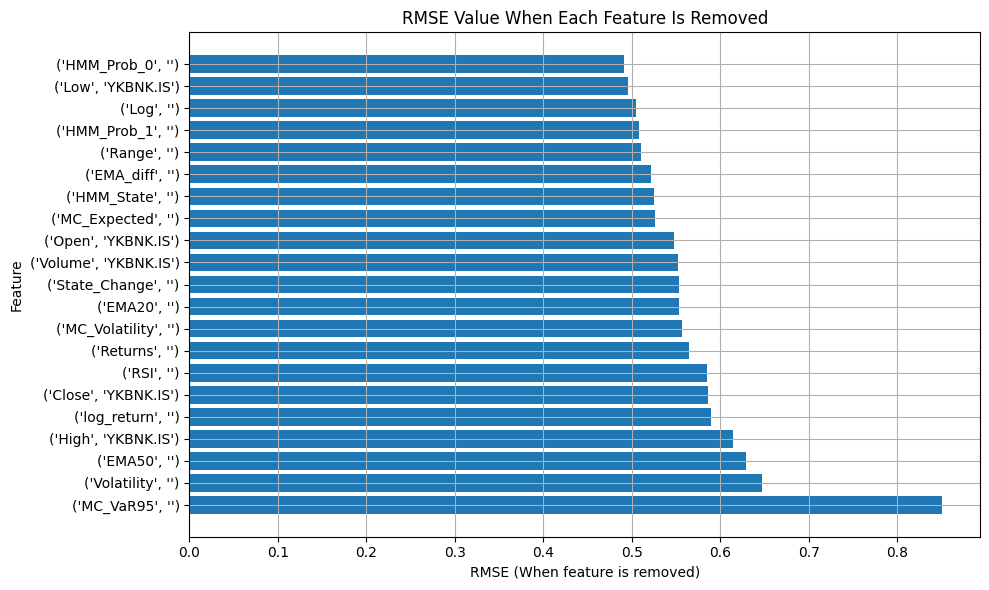

In [ ]:
import copy
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Convert feature names to string
feature_names = [str(col) for col in obs.columns.tolist()]

# Function to train and evaluate the model
def evaluate_model(X, y, scaler, feature_names, removed_feature_index=None):
    X_mod = copy.deepcopy(X)

    # Remove a specific feature
    if removed_feature_index is not None:
        X_mod = np.delete(X_mod, removed_feature_index, axis=2)

    model = Sequential([
        LSTM(64, activation='relu', input_shape=(X_mod.shape[1], X_mod.shape[2])),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    early_stop = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)
    model.fit(X_mod, y, epochs=20, batch_size=16, verbose=0, callbacks=[early_stop])

    preds = model.predict(X_mod, verbose=0)

    predicted_full = np.zeros((len(preds), scaler.n_features_in_))
    predicted_full[:, 3] = preds[:, 0]  # 3: Index of Close price in the scaled array
    restored = scaler.inverse_transform(predicted_full)[:, 3]

    real_close = df['Close'].iloc[-len(restored):].values

    mae = mean_absolute_error(real_close, restored)
    mse = mean_squared_error(real_close, restored)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(real_close, restored) * 100

    return mae, mse, rmse, mape

# Feature elimination analysis
results = []

for i in range(len(feature_names)):
    f_name = feature_names[i]
    print(f"🔍 Removing feature: {f_name}")
    mae, mse, rmse, mape = evaluate_model(X, y, scaler, feature_names, removed_feature_index=i)
    results.append((str(f_name), mae, mse, rmse, mape))  # 🔁 UPDATED LINE

# Display results as a table
results_df = pd.DataFrame(results, columns=['Feature', 'MAE', 'MSE', 'RMSE', 'MAPE'])
results_df = results_df.sort_values(by='RMSE', ascending=True)

# Print
print(results_df)

# Plot: Which feature contributes the most
plt.figure(figsize=(10,6))
plt.barh(results_df['Feature'], results_df['RMSE'])  # ✅ Tuple error no longer present
plt.xlabel("RMSE (When feature is removed)")
plt.ylabel("Feature")
plt.title("RMSE Value When Each Feature Is Removed")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()


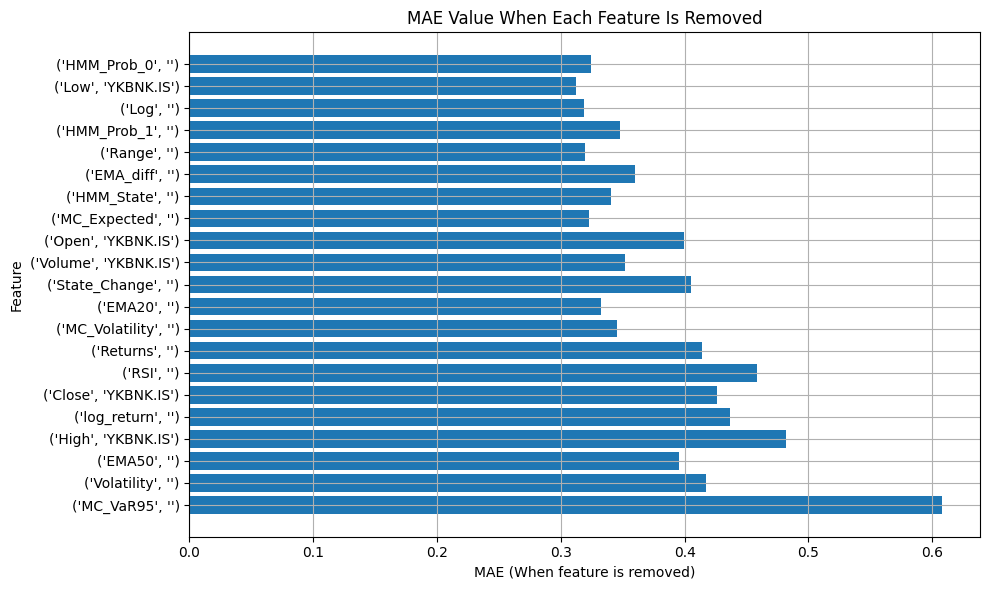

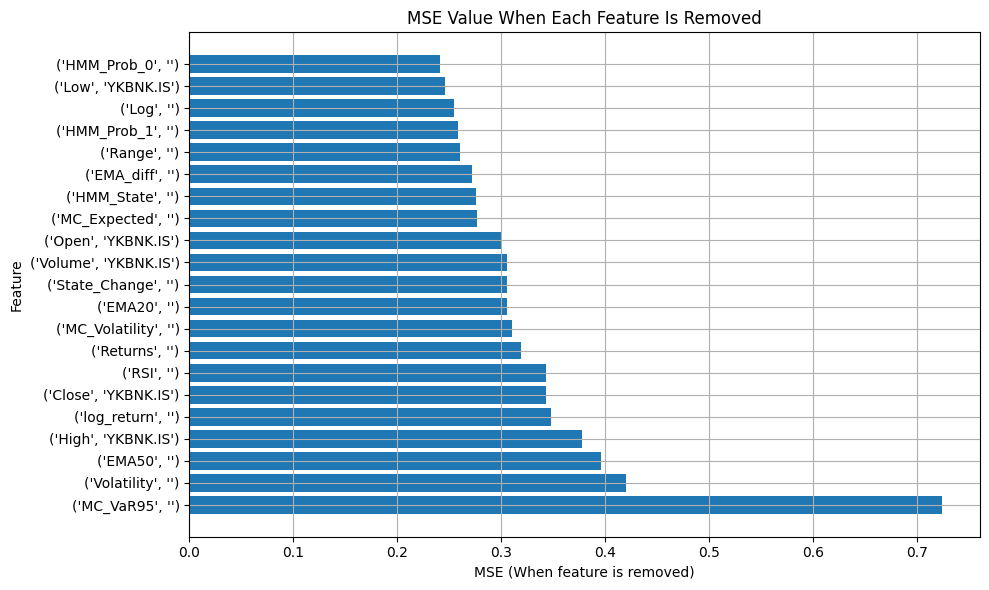

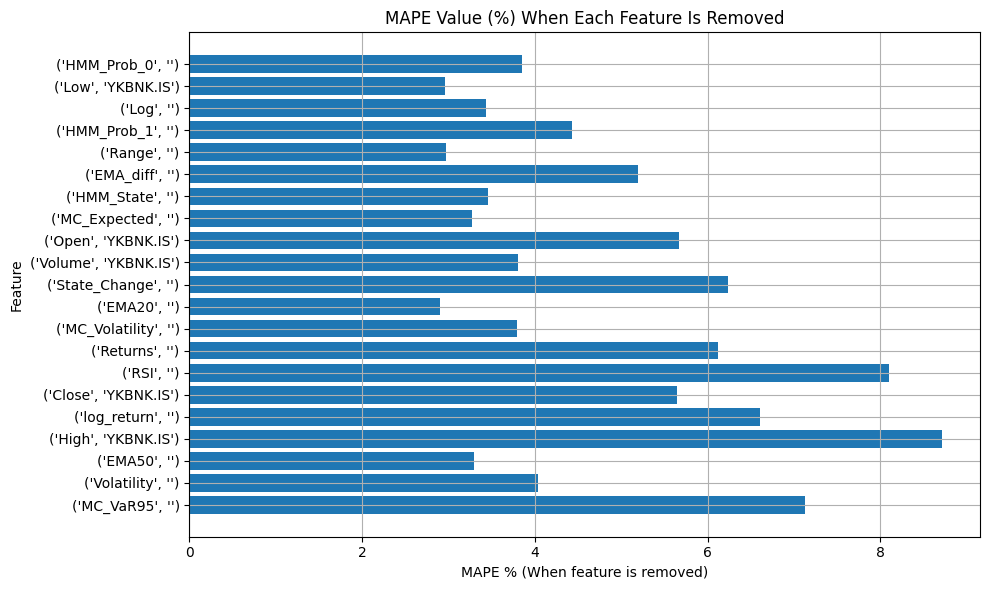

In [ ]:
# MAE Chart
plt.figure(figsize=(10,6))
plt.barh(results_df['Feature'], results_df['MAE'])
plt.xlabel("MAE (When feature is removed)")
plt.ylabel("Feature")
plt.title("MAE Value When Each Feature Is Removed")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

# MSE Chart
plt.figure(figsize=(10,6))
plt.barh(results_df['Feature'], results_df['MSE'])
plt.xlabel("MSE (When feature is removed)")
plt.ylabel("Feature")
plt.title("MSE Value When Each Feature Is Removed")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

# MAPE Chart
plt.figure(figsize=(10,6))
plt.barh(results_df['Feature'], results_df['MAPE'])
plt.xlabel("MAPE % (When feature is removed)")
plt.ylabel("Feature")
plt.title("MAPE Value (%) When Each Feature Is Removed")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_10248\82340867.py:9: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  X_shap = X_shap.drop(columns=['Close'])


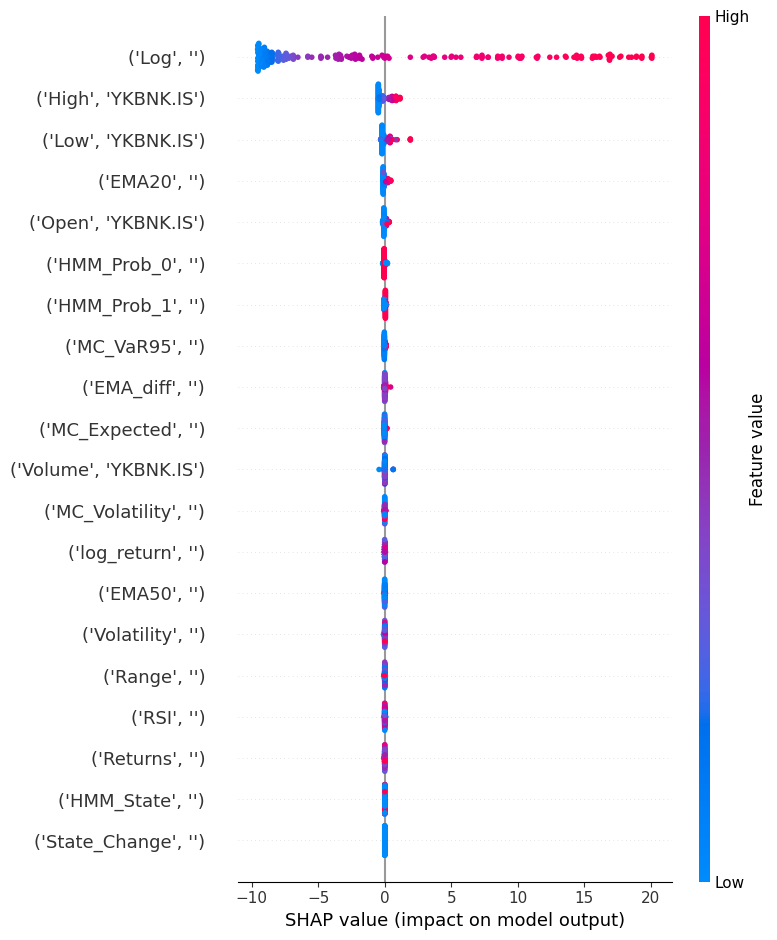

In [ ]:
import shap
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Features and target variable
X_shap = obs.copy()
y_shap = X_shap['Close']
X_shap = X_shap.drop(columns=['Close'])

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_shap, y_shap, test_size=0.2, random_state=42)

# 3. Train the model
model = XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Compute SHAP values
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# 5. Summary plot (feature importance)
shap.summary_plot(shap_values, X_test)


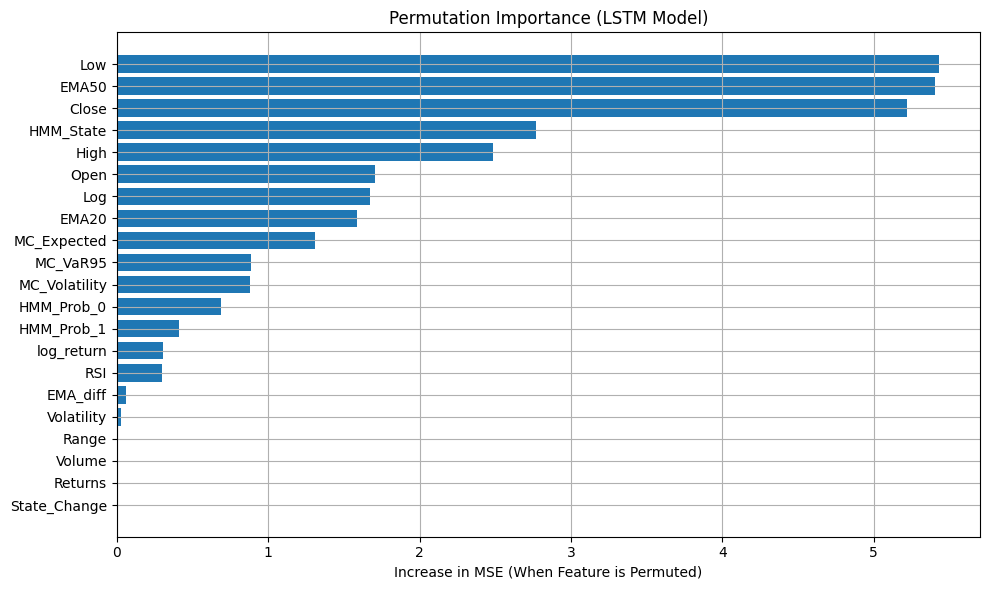

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np
import copy

# Permutation importance function for LSTM
def permutation_importance_lstm(model, X, y, scaler, feature_names):
    base_preds = model.predict(X, verbose=0)
    base_full = np.zeros((len(base_preds), scaler.n_features_in_))
    base_full[:, 3] = base_preds[:, 0]
    base_restored = scaler.inverse_transform(base_full)[:, 3]
    base_score = mean_squared_error(df['Close'].iloc[-len(base_restored):].values, base_restored)

    importances = []
    for i in range(X.shape[2]):
        X_permuted = X.copy()
        np.random.shuffle(X_permuted[:, :, i])
        preds = model.predict(X_permuted, verbose=0)
        pred_full = np.zeros((len(preds), scaler.n_features_in_))
        pred_full[:, 3] = preds[:, 0]
        restored = scaler.inverse_transform(pred_full)[:, 3]
        score = mean_squared_error(df['Close'].iloc[-len(restored):].values, restored)
        importances.append(score - base_score)

    return importances

# Clean up feature names (remove tuple structure if any)
feature_names_clean = [str(col[0]) if isinstance(col, tuple) else str(col) for col in obs.columns]

# Calculate permutation importances
importances = permutation_importance_lstm(model_lstm, X, y, scaler, feature_names_clean)

# Visualization
import matplotlib.pyplot as plt
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': feature_names_clean,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Increase in MSE (When Feature is Permuted)")
plt.title("Permutation Importance (LSTM Model)")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

---------*************
---------*************---------*************---------*************

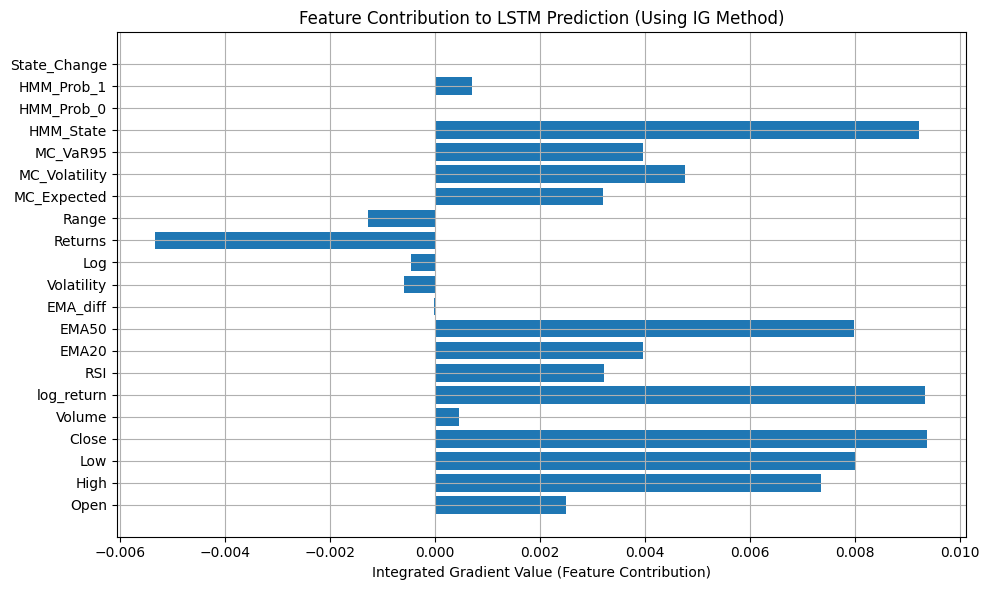

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def integrated_gradients(model, baseline, input_tensor, target_index=None, steps=50):
    # Interpolate inputs between the baseline and the actual input
    interpolated_inputs = [
        baseline + (float(i) / steps) * (input_tensor - baseline)
        for i in range(0, steps + 1)
    ]
    interpolated_inputs = tf.convert_to_tensor(np.array(interpolated_inputs), dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(interpolated_inputs)
        predictions = model(interpolated_inputs)
        if target_index is not None:
            predictions = predictions[:, target_index]

    grads = tape.gradient(predictions, interpolated_inputs)

    avg_grads = tf.reduce_mean(grads[:-1], axis=0).numpy()
    integrated_grads = (input_tensor - baseline).numpy() * avg_grads

    return integrated_grads

# Last sequence (10-day input window)
input_tensor = tf.convert_to_tensor(np.expand_dims(X[-1], axis=0), dtype=tf.float32)

# Baseline: zeros with the same shape as the input
baseline = tf.zeros(shape=input_tensor.shape, dtype=tf.float32)

# Compute Integrated Gradients
ig_attributions = integrated_gradients(model_lstm, baseline[0], input_tensor[0])

# Average across the time steps
avg_ig = np.mean(ig_attributions, axis=0)

# Feature names (flattened if tuple)
feature_names_clean = [str(col[0]) if isinstance(col, tuple) else str(col) for col in obs.columns]

# Visualization
plt.figure(figsize=(10, 6))
plt.barh(feature_names_clean, avg_ig)
plt.xlabel("Integrated Gradient Value (Feature Contribution)")
plt.title("Feature Contribution to LSTM Prediction (Using IG Method)")
plt.grid(True)
plt.tight_layout()
plt.show()


Epoch 1/50


c:\Users\User\anaconda3\envs\stockenv\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0904
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.6476e-04
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.6100e-04
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.5673e-04
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.0576e-04
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.0045e-04
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.2199e-04
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.1870e-04
Epoch 9/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.1561e-04
Epoch 10/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.3644e-04
Epoch 11/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.4332e-04
Epoch 12/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3657e-04
Epoch 13/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1308e-04
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
📊 Final LSTM Model Performance (Selected Features):
MAE  : 0.3175
MSE  : 0.

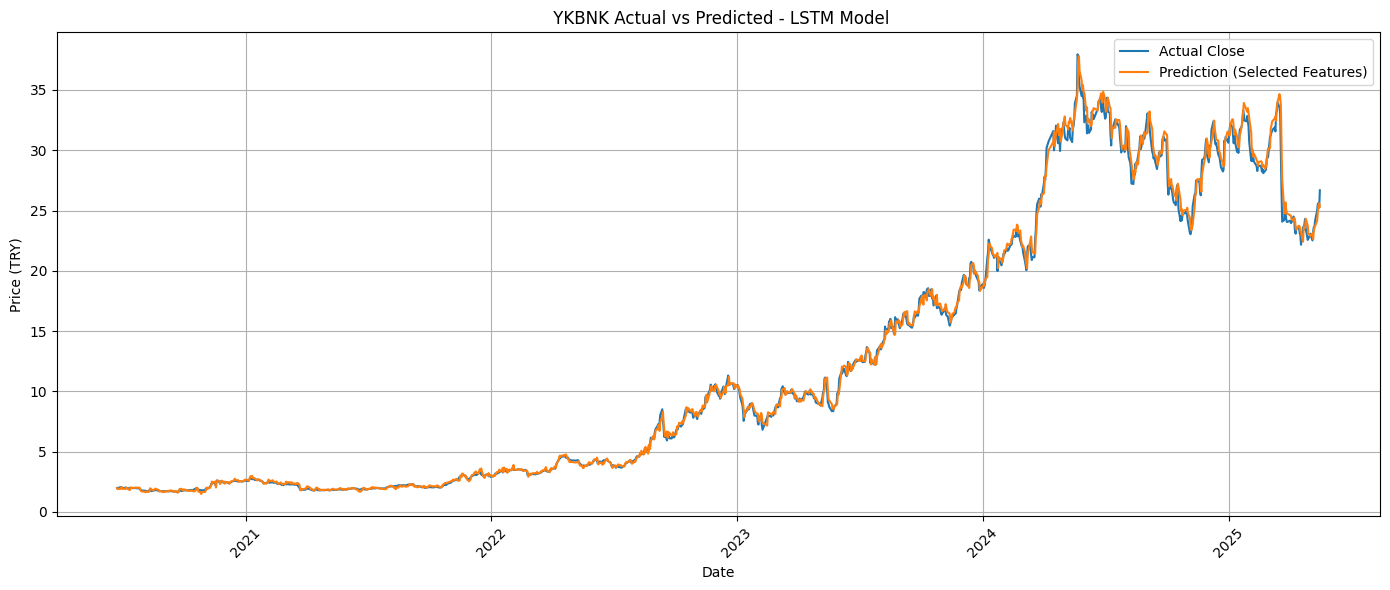

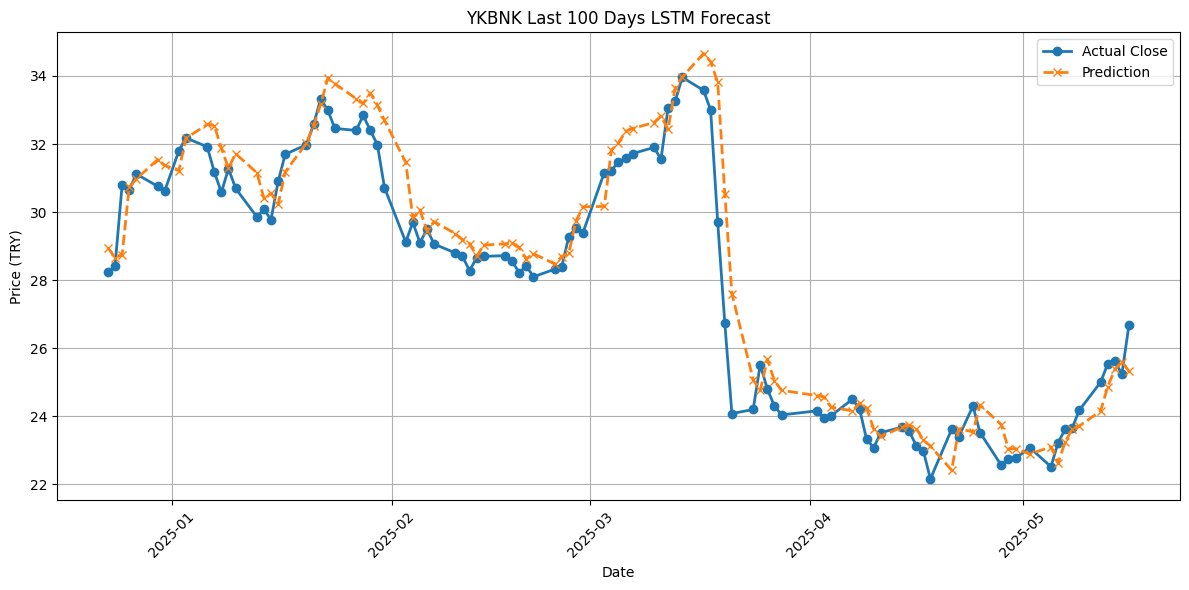

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
📈 Predicted next day closing price: 26.40 TRY


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# 1️⃣ Selected features (HMM + Price + Technical indicators)
selected_features = [
    'Close', 'HMM_Prob_1', 'Low', 'High', 'Log', 'RSI', 'HMM_Prob_0', 'MC_VaR95', 'log_return', 'HMM_State'
]

# 2️⃣ Extract the relevant dataset
df_selected = obs[selected_features].copy().dropna()

# 3️⃣ Normalization
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_selected)

# 4️⃣ Create LSTM dataset
def create_lstm_data(data, seq_len=10):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len][selected_features.index('Close')])
    return np.array(X), np.array(y)

X, y = create_lstm_data(scaled)

# 5️⃣ Define and train the LSTM model
model = Sequential([
    LSTM(64, activation='relu', input_shape=(X.shape[1], X.shape[2])),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
early_stop = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)
model.fit(X, y, epochs=50, batch_size=16, verbose=1, callbacks=[early_stop])

# 6️⃣ Make predictions and inverse transform
preds = model.predict(X)
pred_full = np.zeros((len(preds), scaled.shape[1]))
pred_full[:, selected_features.index('Close')] = preds[:, 0]
restored = scaler.inverse_transform(pred_full)[:, selected_features.index('Close')]

# 7️⃣ Actual values
real = df_selected['Close'].iloc[-len(restored):].values
dates = df_selected.index[-len(restored):]

# 8️⃣ Evaluation metrics
mae = mean_absolute_error(real, restored)
mse = mean_squared_error(real, restored)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(real, restored) * 100

print("📊 Final LSTM Model Performance (Selected Features):")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

# 9️⃣ Full historical prediction plot
plt.figure(figsize=(14, 6))
plt.plot(dates, real, label='Actual Close')
plt.plot(dates, restored, label='Prediction (Selected Features)')
plt.title(' YKBNK Actual vs Predicted - LSTM Model')
plt.xlabel('Date')
plt.ylabel('Price (TRY)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 🔟 Last 100-day detailed plot
plt.figure(figsize=(12, 6))
plt.plot(dates[-100:], real[-100:], marker='o', label='Actual Close', linewidth=2)
plt.plot(dates[-100:], restored[-100:], marker='x', linestyle='--', label='Prediction', linewidth=2)
plt.title("YKBNK Last 100 Days LSTM Forecast")
plt.xlabel("Date")
plt.ylabel("Price (TRY)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 1️⃣1️⃣ Predict the next day
last_seq = scaled[-10:]  # last 10 days
last_seq = np.expand_dims(last_seq, axis=0)
next_day_scaled = model.predict(last_seq)

# Inverse transform the next-day prediction
dummy_input = np.zeros((1, scaled.shape[1]))
dummy_input[0, selected_features.index('Close')] = next_day_scaled[0, 0]
next_day_close = scaler.inverse_transform(dummy_input)[0, selected_features.index('Close')]

print(f"📈 Predicted next day closing price: {next_day_close:.2f} TRY")


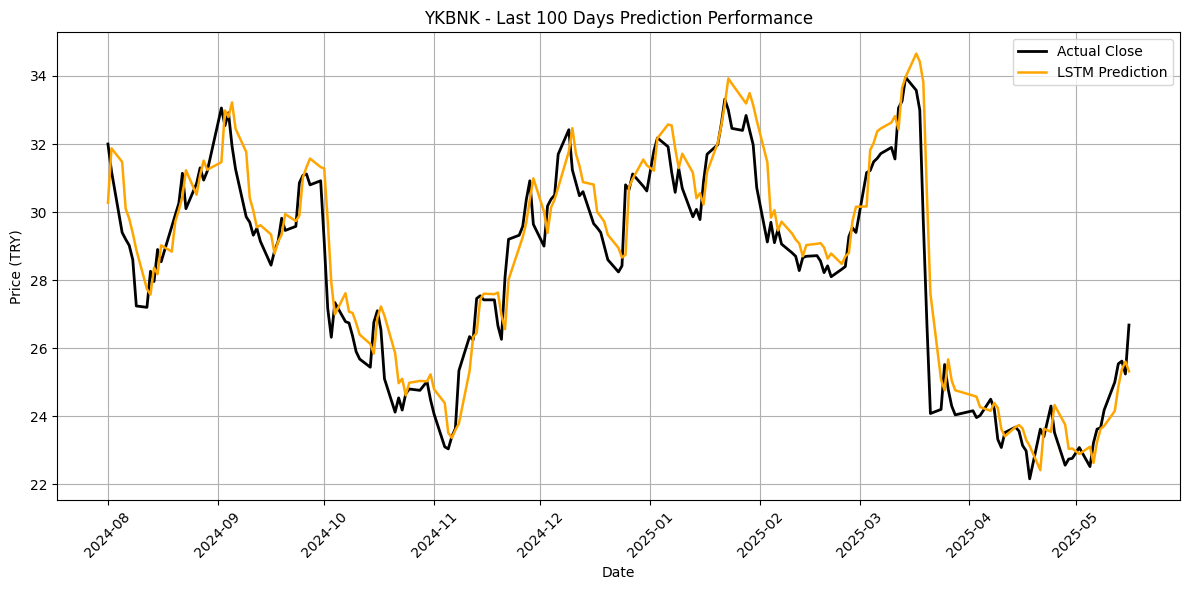

In [ ]:
# 🔹 Last 100-day prediction comparison
real_last_100 = real[-200:]
pred_last_100 = restored[-200:]
dates_last_100 = dates[-200:]

plt.figure(figsize=(12, 6))
plt.plot(dates_last_100, real_last_100, label='Actual Close', color='black', linewidth=2)
plt.plot(dates_last_100, pred_last_100, label='LSTM Prediction', color='orange', linestyle='-', linewidth=1.8)
plt.title("YKBNK - Last 100 Days Prediction Performance")
plt.xlabel("Date")
plt.ylabel("Price (TRY)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


💰 Starting Capital  : 100000.00 TRY
📈 Final Portfolio Value : 300851.14 TRY
🔁 Total Profit/Loss     : 200851.14 TRY


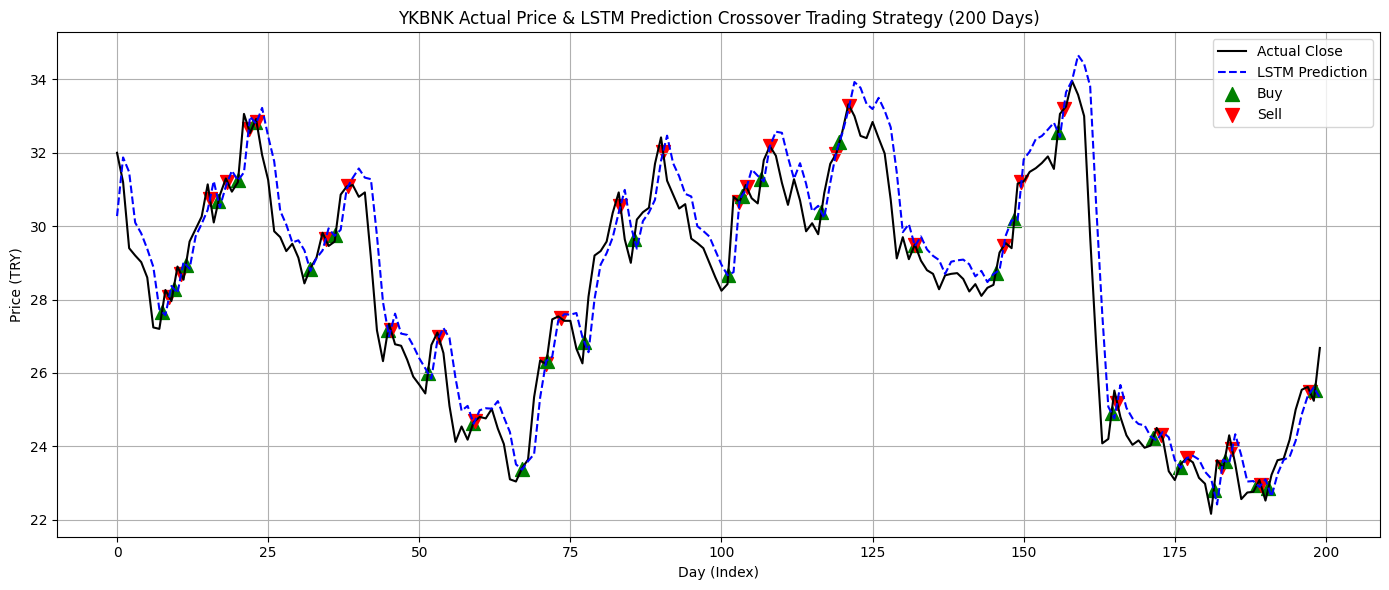

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1️⃣ Data (last 200 days)
close = df_selected['Close'].values[-200:]      # Actual prices
predicted = np.array(restored[-200:])           # LSTM predictions

# 2️⃣ Initial capital and setup
capital = 100000
cash = capital
position = 0
trade_log = []

# 3️⃣ Crossover detection
for i in range(len(close) - 1):
    diff_now = close[i] - predicted[i]
    diff_next = close[i + 1] - predicted[i + 1]

    if diff_now * diff_next < 0:  # Crossover detected
        alpha = abs(diff_now) / (abs(diff_now) + abs(diff_next))
        cross_index = i + alpha

        # Estimate the crossover price on the actual close line
        price_cross = close[i] + alpha * (close[i + 1] - close[i])

        if diff_now < 0 and diff_next > 0:  # Actual price crosses above prediction → BUY
            if cash > 0:
                position = cash / price_cross
                cash = 0
                trade_log.append(('Buy', cross_index, price_cross))

        elif diff_now > 0 and diff_next < 0:  # Actual price crosses below prediction → SELL
            if position > 0:
                cash = position * price_cross
                position = 0
                trade_log.append(('Sell', cross_index, price_cross))

# 4️⃣ Close final position if any
final_value = cash if position == 0 else position * close[-1]
total_profit = final_value - capital

# 5️⃣ Print results
print(f"💰 Starting Capital  : {capital:.2f} TRY")
print(f"📈 Final Portfolio Value : {float(final_value):.2f} TRY")
print(f"🔁 Total Profit/Loss     : {float(total_profit):.2f} TRY")

plt.figure(figsize=(14, 6))
plt.plot(close, label='Actual Close', color='black')
plt.plot(predicted, label='LSTM Prediction', color='blue', linestyle='--')

# Mark buy/sell actions
for action, idx, price in trade_log:
    if action == 'Buy':
        plt.scatter(idx, price, marker='^', color='green', s=100, label='Buy')
    elif action == 'Sell':
        plt.scatter(idx, price, marker='v', color='red', s=100, label='Sell')

# Show unique labels only
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.title("YKBNK Actual Price & LSTM Prediction Crossover Trading Strategy (200 Days)")
plt.xlabel("Day (Index)")
plt.ylabel("Price (TRY)")
plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
# 🔁 Buy-Sell pair matching with quantity and cost tracking
trade_pairs = []

for i in range(0, len(trade_log) - 1, 2):
    if trade_log[i][0] == 'Buy' and trade_log[i + 1][0] == 'Sell':
        buy_index = trade_log[i][1]
        buy_price = trade_log[i][2]
        sell_index = trade_log[i + 1][1]
        sell_price = trade_log[i + 1][2]

        # Calculate how many units were bought at that price
        quantity = capital / buy_price
        total_buy_cost = quantity * buy_price
        total_sell_revenue = quantity * sell_price

        gain = total_sell_revenue - total_buy_cost
        profit_percent = (gain / total_buy_cost) * 100

        trade_pairs.append({

            "Buy Price": round(float(buy_price), 2),

            "Sell Price": round(float(sell_price), 2),
            "Buy Quantity": round(float(quantity), 2),
            "Total Buy Cost": round(float(total_buy_cost), 2),
            "Total Sell Revenue": round(float(total_sell_revenue), 2),
            "Profit (TRY)": round(float(gain), 2),
            "Profit (%)": round(float(profit_percent), 2),
            "Successful?": "✅" if gain > 0 else "❌"
        })

# 📊 Create summary DataFrame
trade_summary_df = pd.DataFrame(trade_pairs)

# 📋 Display full table
pd.set_option('display.max_rows', None)
print("\n📈 Trade Summary (Buy-Sell Pairs with Quantity):\n")
print(trade_summary_df.to_string(index=False))

# 📊 Calculate success rate
total_trades = len(trade_summary_df)
successful_trades = (trade_summary_df["Successful?"] == "✅").sum()
success_rate = successful_trades / total_trades * 100 if total_trades > 0 else 0

print(f"\n📊 Total Number of Trades : {total_trades}")
print(f"✅ Successful Trades       : {successful_trades}")
print(f"🏆 Success Rate            : {success_rate:.2f}%")


📈 Trade Summary (Buy-Sell Pairs with Quantity):

 Buy Price  Sell Price  Buy Quantity  Total Buy Cost  Total Sell Revenue  Profit (TRY)  Profit (%) Successful?
     27.67       28.07       3614.54        100000.0           101468.79       1468.79        1.47           ✅
     28.30       28.68       3533.60        100000.0           101357.19       1357.19        1.36           ✅
     28.95       30.74       3454.33        100000.0           106199.64       6199.64        6.20           ✅
     30.67       31.20       3260.24        100000.0           101726.29       1726.29        1.73           ✅
     31.25       32.65       3200.01        100000.0           104493.40       4493.40        4.49           ✅
     32.84       32.83       3045.30        100000.0            99987.80        -12.20       -0.01           ❌
     28.83       29.64       3469.10        100000.0           102822.36       2822.36        2.82           ✅
     29.76       31.09       3360.18        100000.0          